<a href="https://colab.research.google.com/github/AleksandrMac/learning/blob/main/ai/practic/2/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2. Ассистент сметчика
## 📖 Описание проекта
RAG-система для работы с нормативной базой сметного дела, реализованная на примере **«Методики 421»** (приказ Минстроя РФ) и одного из официальных дополнений к ней. Проект решает ключевую проблему нормативного поиска: корректный учёт версионности и предоставление контекста строго на заданную дату. Архитектура спроектирована с учётом дальнейшего масштабирования на смежные строительные домены (проектирование, управление, эксплуатация).

### 🔬 Сравнительный эксперимент (этап подготовки данных)
На этапе индексации проводится сравнение двух подходов к построению графа знаний и векторизации:
| Подход | Реализация | Оцениваемые метрики |
|--------|------------|---------------------|
| **🔹 Custom Graph (`networkx`)** | Ручная экстракция сущностей, явное хранение связей `документ → пункт → изменение`, темпоральные фильтры на уровне приложения | • Точность временных срезов (`Accuracy@Date`)<br>• Время индексации<br>• Latency retrieval<br>• Контроль галлюцинаций |
| **🔹 LightRAG** | Автоматическая экстракция связей через LLM, встроенный dual-level retrieval, инкрементальное обновление | • Полнота захвата зависимостей<br>• Скорость индексации/поиска<br>• Стабильность на шумных данных<br>• Качество обогащения контекста |

Результаты эксперимента фиксируются в виде бенчмарк-отчёта и включают сравнительные таблицы, графики latency и примеры ошибок каждого подхода.

### 🤖 Генерация ответов
- **Основная модель:** `Qwen2.5` (Instruct) — высокая точность на технической документации, нативная поддержка русского языка.
- **Бэзлайн для сравнения:** русскоязычная модель (например, `Saiga-Llama3-8B` или `ruGPT-3.5`) для оценки влияния архитектуры retrieval на итоговое качество генерации.
- Все ответы сопровождаются трассировкой источников с указанием номера пункта, документа-основания и даты актуальности.

### 🛠️ Технологический стек
`Python` • `LangChain` • `ChromaDB` • `NetworkX` • `LightRAG` • `SentenceTransformers` • `Qwen2.5` • `Google Colab`

## Подготовка данных


### Загрузка данных

Функция `load_source_data()` обеспечивает:
- ✅ Проверку наличия файла перед скачиванием (`skip_existing`)
- ✅ Приоритет: прямой `url` → конструирование из `MAIN_URL_MASK + publication_number`
- ✅ Повторные попытки при сбоях сети (`MAX_RETRIES`)
- ✅ Опциональную верификацию по MD5-хэшу
- ✅ Структурированный результат для интеграции с пайплайном

Для Colab: базовая директория `/content`, для локальной разработки — укажите `base_dir="./data"`.

In [ ]:
# @title
# 📦 Ячейка: Загрузчик нормативных документов с проверкой и fallback
import os
import time
import hashlib
import requests
from pathlib import Path
from typing import List, Dict, Optional
from urllib.parse import urlparse

# ⚙️ Настройки
MAIN_URL_MASK = "http://publication.pravo.gov.ru/file/pdf?eoNumber={}"
DOWNLOAD_TIMEOUT = 60  # секунд
MAX_RETRIES = 3
RETRY_DELAY = 2  # секунд

def _calculate_file_hash(filepath: str, algorithm: str = "md5") -> Optional[str]:
    """Вычисляет хэш файла для проверки целостности."""
    if not os.path.exists(filepath):
        return None
    hash_func = hashlib.new(algorithm)
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_func.update(chunk)
    return hash_func.hexdigest()

def _resolve_url(item: Dict) -> Optional[str]:
    """Определяет URL для скачивания: прямой URL → маска + publication_number."""
    # Приоритет 1: прямой URL (если есть и не пустой после trim)
    if url := item.get("url", "").strip():
        return url

    # Приоритет 2: сконструировать из маски + publication_number
    if pub_num := item.get("publication_number", "").strip():
        if MAIN_URL_MASK:
            return MAIN_URL_MASK.format(pub_num)

    return None

def _ensure_directory(filepath: str) -> bool:
    """Создаёт директорию для файла, если не существует."""
    try:
        Path(filepath).parent.mkdir(parents=True, exist_ok=True)
        return True
    except Exception as e:
        print(f"❌ Ошибка создания директории для {filepath}: {e}")
        return False

def download_file(url: str, filepath: str, timeout: int = DOWNLOAD_TIMEOUT) -> bool:
    """Скачивает файл с прогресс-баром и обработкой ошибок."""
    try:
        response = requests.get(url, stream=True, timeout=timeout)
        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))
        downloaded = 0

        with open(filepath, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    # Прогресс для Colab
                    if total_size > 0:
                        percent = min(100, int(100 * downloaded / total_size))
                        print(f"\r⬇️  {Path(filepath).name}: {percent}% ", end="")

        print(f"\r✅ {Path(filepath).name}: загрузка завершена")
        return True

    except requests.exceptions.RequestException as e:
        print(f"\n❌ Ошибка загрузки {url}: {e}")
        return False
    except IOError as e:
        print(f"\n❌ Ошибка записи файла {filepath}: {e}")
        return False

def load_source_data(
    input_data: List[Dict],
    base_dir: str = "/content",
    skip_existing: bool = True,
    verify_hash: bool = False,
    expected_hashes: Optional[Dict[str, str]] = None
) -> List[Dict]:
    """
    Загружает нормативные документы с проверкой наличия и целостности.

    Args:
        input_data: Список словарей с метаданными документов
        base_dir: Базовая директория для сохранения (по умолчанию /content для Colab)
        skip_existing: Пропускать уже скачанные файлы (проверка по размеру > 0)
        verify_hash: Проверять целостность по MD5-хэшу
        expected_hashes: Словарь {filepath: expected_hash} для верификации

    Returns:
        Список результатов загрузки с метаданными и статусом
    """
    results = []

    for idx, item in enumerate(input_data, 1):
        print(f"\n[{idx}/{len(input_data)}] Обработка: {item.get('name', 'Без названия')[:60]}...")

        # Резолвим путь к файлу
        rel_path = item.get("file", "").strip()
        if not rel_path:
            print("⚠️  Пропуск: не указан путь к файлу (field 'file')")
            results.append({**item, "status": "skipped", "reason": "no_file_path"})
            continue

        filepath = os.path.join(base_dir, rel_path) if not rel_path.startswith("/") else rel_path

        # Проверка: файл уже существует
        if skip_existing and os.path.exists(filepath) and os.path.getsize(filepath) > 0:
            # Опциональная проверка хэша
            if verify_hash and expected_hashes:
                current_hash = _calculate_file_hash(filepath)
                expected = expected_hashes.get(filepath)
                if current_hash != expected:
                    print(f"⚠️  Хэш не совпадает. Перезагрузка...")
                else:
                    print(f"✅ Файл уже загружен и верифицирован: {filepath}")
                    results.append({**item, "status": "cached", "filepath": filepath})
                    continue
            else:
                print(f"✅ Файл уже загружен: {filepath}")
                results.append({**item, "status": "cached", "filepath": filepath})
                continue

        # Создаём директорию
        if not _ensure_directory(filepath):
            results.append({**item, "status": "failed", "reason": "mkdir_failed"})
            continue

        # Определяем URL
        url = _resolve_url(item)
        if not url:
            print("⚠️  Пропуск: не удалось определить URL для скачивания")
            results.append({**item, "status": "skipped", "reason": "no_url"})
            continue

        print(f"🔗 URL: {url}")

        # Скачивание с повторами
        success = False
        for attempt in range(MAX_RETRIES):
            if download_file(url, filepath):
                success = True
                break
            print(f"🔄 Попытка {attempt + 2}/{MAX_RETRIES} через {RETRY_DELAY}с...")
            time.sleep(RETRY_DELAY)

        if not success:
            results.append({**item, "status": "failed", "reason": "download_failed", "url": url})
            continue

        # Финальная верификация (если запрошена)
        if verify_hash and expected_hashes:
            current_hash = _calculate_file_hash(filepath)
            expected = expected_hashes.get(filepath)
            if current_hash != expected:
                print(f"❌ Хэш не совпадает! Ожид: {expected}, Получено: {current_hash}")
                results.append({**item, "status": "failed", "reason": "hash_mismatch"})
                continue

        results.append({
            **item,
            "status": "downloaded",
            "filepath": filepath,
            "size_bytes": os.path.getsize(filepath)
        })

    # 📊 Итоговая статистика
    stats = {
        "total": len(input_data),
        "downloaded": sum(1 for r in results if r["status"] == "downloaded"),
        "cached": sum(1 for r in results if r["status"] == "cached"),
        "failed": sum(1 for r in results if r["status"] == "failed"),
        "skipped": sum(1 for r in results if r["status"] == "skipped")
    }

    print(f"\n📈 Статистика загрузки: {stats}")
    return results

In [ ]:
# @title
main_url_mask="http://publication.pravo.gov.ru/file/pdf?eoNumber=%1"
# reserve_url_mask="https://github.com/AleksandrMac/learning/tree/main/ai/practic/2/data/pdf/%1"
# Структура исходных данных
input_data = [
    {
        "original_text":"",
        "file":"data/pdf/20200804_421.pdf",
        "name":"Методика определения сметной стоимости строительства, реконструкции, капитального ремонта, сноса объектов капитального строительства, работ по сохранению объектов культурного наследия (памятников истории и культуры) народов Российской Федерации на территории Российской Федерации",
        "valid_from": "04.08.2020",
        "valid_to": None,
        "publication_date":   "24.09.2020",
        "publication_number": "0001202009240006",
        "registration_date":  "23.09.2020",
        "registration_number": 59986,
        "type": "base"
    }
]
# 🔐 Опционально: хэши для верификации (если есть эталон)
expected_hashes = {
    "/content/data/pdf/20200804_421.pdf": "abc123def456..."
}

# 🚀 Запуск загрузчика
results = load_source_data(
    input_data=input_data,
    base_dir=".",
    skip_existing=True,      # не качать повторно
    verify_hash=False,       # включить, если есть expected_hashes
    expected_hashes=expected_hashes
)

# 📥 Результат для следующего шага пайплайна
ready_docs = [r for r in results if r["status"] in ("downloaded", "cached")]
print(f"\n✅ Готово к парсингу: {len(ready_docs)} документов")


[1/1] Обработка: Методика определения сметной стоимости строительства, реконс...
🔗 URL: http://publication.pravo.gov.ru/file/pdf?eoNumber=0001202009240006
✅ 20200804_421.pdf: загрузка завершена

📈 Статистика загрузки: {'total': 1, 'downloaded': 1, 'cached': 0, 'failed': 0, 'skipped': 0}

✅ Готово к парсингу: 1 документов


### 🖼️ Обработка сканированных документов
Система использует **гибридный парсер**:
1. Нативное извлечение текста (`pdfplumber`) для векторных PDF
2. Постраничный OCR-fallback (`Tesseract + pdf2image`) при обнаружении сканов
3. Порог срабатывания: `<30 символов на страницу` → триггерит распознавание

Для табличных частей ГЭСН/ФЕР рекомендуется модуль `camelot-py` (в roadmap).

In [ ]:
%pip install -q pdfplumber chardet

# import json
import chardet
from pathlib import Path
# from typing import List, Dict, Optional

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# @title
# 📦 Установка системных и Python-зависимостей
!apt-get install -y tesseract-ocr tesseract-ocr-rus tesseract-ocr-eng poppler-utils > /dev/null
!pip install -q pdfplumber pytesseract pdf2image > /dev/null

import pdfplumber
import pytesseract
from pdf2image import convert_from_path
import re, os
from pathlib import Path

def extract_text_smart(pdf_path: str, min_char_threshold: int = 30) -> str:
    """
    1. Пробует извлечь текст через pdfplumber (быстро, точно)
    2. Если символов < threshold → конвертирует страницы в изображения и запускает Tesseract OCR
    3. Возвращает объединённый текст
    """
    print(f"🔍 Анализ {Path(pdf_path).name}...")
    full_text = []
    ocr_triggered = False

    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            txt = page.extract_text() or ""
            # Если на странице мало символов → вероятна картинка/скан
            if len(txt.strip()) < min_char_threshold:
                if not ocr_triggered:
                    print(f"   ⚠️ Страница {i+1}: текст не найден. Запускаю OCR...")
                    ocr_triggered = True

                # Конвертируем только текущую страницу в изображение
                img = convert_from_path(pdf_path, first_page=i+1, last_page=i+1, dpi=200)[0]
                txt = pytesseract.image_to_string(img, lang='rus+eng+math')

            full_text.append(txt.strip())

    result = "\n".join(full_text)

    if ocr_triggered:
        print(f"✅ OCR завершён. Итого символов: {len(result)}")
    else:
        print(f"✅ Текст извлечён нативно. Символов: {len(result)}")

    return result

### парсинг при помощи регулярных выражений

In [ ]:
##### @title
# 📄 Ячейка 2: Ядро парсера (улучшенная версия)
import re
from typing import List, Dict, Optional
from pathlib import Path

def clean_pdf_text(text: str) -> str:
    """
    Удаляет колонтитулы, номера страниц и артефакты печати.
    Оптимизировано под российские нормативные документы.
    """
    # Удаляем типичные колонтитулы (стр. 5, Лист 12, даты, номера приказов)
    footer_patterns = [
        r'^.*?\bстр\.?\s*\d+\b.*?$',           # "стр. 5", "стр 12"
        r'^.*?\bлист\.?\s*\d+\b.*?$',          # "Лист 12"
        r'^.*?\b\d{2}\.\d{2}\.\d{4}\b.*?$',    # даты в колонтитулах
        r'^.*?\b№\s*[\d/–-]+\b.*?$',           # номера документов
    ]

    for pattern in footer_patterns:
        text = re.sub(pattern, '', text, flags=re.MULTILINE | re.IGNORECASE)

    # Схлопываем множественные переносы и лишние пробелы
    text = re.sub(r'\n\s*\n', '\n', text)           # пустые строки
    text = re.sub(r'[ \t]+', ' ', text)             # лишние пробелы
    text = re.sub(r'\n\s+', '\n', text)             # пробелы после переноса

    return text.strip()


def extract_clauses(text: str, min_clause_len: int = 10) -> List[Dict[str, str]]:
    """
    Парсит текст в пункты с гибкой поддержкой российской нумерации.

    Поддерживаемые форматы:
    - Римские: II, III.1, IV.2.3
    - Арабские: 1, 1.1, 2.3.4, 1), 2)
    - Буквенные: а), б), в), г)
    - Вложенные: 1.1.1, а.1, (а)
    """
    # Расширенный паттерн с именованными группами
    clause_re = re.compile(
        r'''^
        \s*
        (?P<id>
            # Римские цифры: II, III.1, IV.2.3
            (?:[IVXLCDM]+(?:\.[\d.]+)?)|
            # Арабские: 1, 1.1, 2.3.4, 1), 1.
            (?:\d+(?:\.\d+)*[\.\)]?)|
            # Буквенные: а), б), (а), а.
            (?:\([а-яё]\)|[а-яё][\.\)]?)
        )
        \s+
        (?P<rest>.*)
        ''',
        re.MULTILINE | re.VERBOSE | re.IGNORECASE
    )

    clauses = []
    current_id = None
    current_text = []

    for match in clause_re.finditer(text):
        # Сохраняем предыдущий пункт
        if current_id:
            full_text = " ".join(current_text).strip()
            if len(full_text) >= min_clause_len:
                clauses.append({"id": current_id, "text": full_text})

        current_id = match.group("id").strip()
        current_text = [match.group("rest").strip()]

    # Не забываем последний пункт
    if current_id:
        full_text = " ".join(current_text).strip()
        if len(full_text) >= min_clause_len:
            clauses.append({"id": current_id, "text": full_text})

    return clauses


def parse_amendment_text(text: str) -> List[Dict[str, str]]:
    """
    Извлекает изменения из текста дополнений.

    Поддерживаемые форматы:
    - "Пункт X изложить в следующей редакции: ..."
    - "Дополнить пунктом X следующего содержания: ..."
    - "Пункт X признать утратившим силу"
    - "В пункте X слова '...' заменить на '...'"
    """
    changes = []

    # Паттерны для разных типов изменений
    patterns = [
        # "изложить в следующей редакции"
        (
            r'пункт\s+([^\s:;,]+)\s+изложить\s+в\s+следующей\s+редакции[:\s]*([\s\S]*?)(?=(?:пункт\s+|$|\Z|дополнить|признать))',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": m.group(2).strip(), "change_type": "replace"}
        ),
        # "дополнить пунктом"
        (
            r'дополнить\s+пунктом\s+([^\s:;,]+)\s+следующего\s+содержания[:\s]*([\s\S]*?)(?=(?:пункт\s+|$|\Z|изложить|признать))',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": m.group(2).strip(), "change_type": "add"}
        ),
        # "признать утратившим силу"
        (
            r'пункт\s+([^\s:;,]+)\s+признать\s+утратившим\s+силу',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": "", "change_type": "delete"}
        ),
        # "заменить слова"
        (
            r'в\s+пункте\s+([^\s:;,]+)\s+слова\s+[\'"]([^\'"]+)[\'"]\s+заменить\s+на\s+[\'"]([^\'"]+)[\'"]',
            lambda m: {
                "target_clause": m.group(1).strip(),
                "old_text": m.group(2).strip(),
                "new_text": m.group(3).strip(),
                "change_type": "modify"
            }
        ),
    ]

    for pattern, extractor in patterns:
        for match in re.finditer(pattern, text, re.IGNORECASE):
            change = extractor(match)
            if change.get("target_clause") and change.get("new_text") is not None:
                changes.append(change)

    return changes


def generate_doc_id(title: str, publication_number: Optional[str] = None) -> str:
    """
    Генерирует стабильный ID документа.
    Приоритет: publication_number → заголовок → имя файла.
    """
    if publication_number:
        return f"PN_{publication_number}"

    # Очищаем заголовок от спецсимволов
    clean_title = re.sub(r'[^a-zA-Zа-яА-Я0-9_\s]', '', title)
    # Берём первые значимые слова
    words = [w for w in clean_title.split() if len(w) > 3][:3]
    return "_".join(words).upper()[:50] if words else "UNKNOWN_DOC"


def process_normative_pdf(
    pdf_path: str,
    doc_type: str = "base",
    valid_from: Optional[str] = None,
    publication_number: Optional[str] = None,
    min_clause_len: int = 10
) -> Dict:
    """
    Основная функция парсинга нормативных документов.

    Args:
        pdf_path: Путь к PDF-файлу
        doc_type: 'base' или 'amendment'
        valid_from: Дата вступления в силу (ISO format)
        publication_number: Номер публикации для стабильного ID
        min_clause_len: Минимальная длина пункта для фильтрации шума

    Returns:
        Словарь с метаданными и извлечённой структурой
    """
    # Извлекаем текст с умным fallback на OCR
    full_text = extract_text_smart(pdf_path)
    full_text = clean_pdf_text(full_text)

    if not full_text or len(full_text) < 50:
        raise ValueError(f"⚠️  Не удалось извлечь текст из {Path(pdf_path).name}")

    # Извлечение заголовка (первые непустые строки)
    title_lines = [line.strip() for line in full_text.split('\n')[:5] if len(line.strip()) > 20]
    title = title_lines[0] if title_lines else Path(pdf_path).stem

    result = {
        "id": generate_doc_id(title, publication_number),
        "title": title,
        "type": doc_type,
        "valid_from": valid_from,
        "valid_to": None,
        "source_file": str(Path(pdf_path).resolve()),
        "char_count": len(full_text)
    }

    if doc_type == "base":
        clauses = extract_clauses(full_text, min_clause_len=min_clause_len)
        result["clauses"] = clauses
        result["clause_count"] = len(clauses)

    elif doc_type == "amendment":
        changes = parse_amendment_text(full_text)
        result["changes"] = changes
        result["change_count"] = len(changes)

        # Более надёжная эвристика для связи с базовым документом
        if publication_number:
            # Пытаемся извлечь номер базового документа из названия
            base_match = re.search(r'к\s+методике\s*[\d/]*\s*[\(#]?(\d+)', title, re.IGNORECASE)
            if base_match:
                result["amends"] = f"PN_{base_match.group(1)}"

    return result

In [ ]:
# @title
import os
import json
from pathlib import Path
from typing import Dict, Any, Optional

def save_parsed_json(
    data: Dict[str, Any],
    filename: str,
    base_dir: str = "/content"
) -> Optional[str]:
    """
    Сохраняет распарсенный нормативный документ в JSON.

    Args:
        data: Словарь с метаданными, пунктами/изменениями
        filename: Имя файла (без расширения или с .json)
        base_dir: Базовая директория (по умолчанию /content для Colab)

    Returns:
        Путь к сохранённому файлу или None при ошибке
    """
    # Нормализуем имя файла
    if not filename.lower().endswith(".json"):
        filename += ".json"

    output_path = Path(base_dir) / "data" / "json" / filename

    # Создаём структуру директорий, если её нет
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # Валидация перед записью
    if not data or not isinstance(data, dict):
        print(f"⚠️  Пропуск: пустые или некорректные данные для {filename}")
        return None

    try:
        with open(output_path, "w", encoding="utf-8") as f:
            # default=str безопасно обрабатывает datetime, Path и другие non-serializable типы
            json.dump(data, f, ensure_ascii=False, indent=2, default=str)

        print(f"✅ JSON сохранён: {output_path} ({os.path.getsize(output_path) / 1024:.1f} KB)")
        return str(output_path)

    except PermissionError:
        print(f"❌ Ошибка прав доступа: {output_path}")
    except IOError as e:
        print(f"❌ Ошибка записи файла {output_path}: {e}")
    except Exception as e:
        print(f"❌ Неожиданная ошибка при сохранении {filename}: {e}")

    return None

In [ ]:
for r in results:
    parsed_result = process_normative_pdf(r["file"], doc_type=r["type"], valid_from = r["valid_from"])
    saved_path = save_parsed_json(
        data=parsed_result,
        filename=r["file"],
        base_dir=".")

🔍 Анализ 20200804_421.pdf...
   ⚠️ Страница 1: текст не найден. Запускаю OCR...
✅ OCR завершён. Итого символов: 235530
✅ JSON сохранён: data/json/data/pdf/20200804_421.pdf.json (113.9 KB)


при попытке распарсить пдф файл с базового источника результат получился, мягко сказать не очень
![image-2.png](attachment:image-2.png)
-------------->
![image.png](attachment:image.png)

#### парсинг при помощи llm

#### подключение модели

In [ ]:
!pip install -q transformers accelerate torch json_repair > /dev/null
import torch, re, json, os
from transformers import pipeline
from json_repair import repair_json

# Загрузка модели (3B помещается в ~6GB VRAM, оставляет место под чанки)
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
print("📥 Загрузка Qwen2.5-3B-Instruct...")
llm = pipeline(
    "text-generation",
    model=MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    max_new_tokens=2000,
    temperature=0.1,
    do_sample=False,
    return_full_text=False
)
print("✅ Модель готова")

KeyboardInterrupt: 

#####  LLM-парсер с валидацией и чанкингом

In [ ]:
SYSTEM_PROMPT = """Ты эксперт по парсингу нормативно-технической документации РФ.
Твоя задача: извлечь структуру документа в строгом JSON-формате.
ПРАВИЛА:
1. Сохраняй точную нумерацию пунктов (II.1, 1.1, 2.3.4, а), б) и т.д.)
2. Не изменяй смысл текста, только убирай мусор (колонтитулы, разрывы строк, артефакты OCR)
3. Для дополнений указывай: target (целевой пункт), type (replace/add/delete), new_text
4. Если текст обрывается, помети это в поле "truncated": true
5. Верни ТОЛЬКО валидный JSON. Никаких пояснений, markdown или обёрток."""

def chunk_text(text: str, max_chars: int = 3500) -> list[str]:
    """Разбивает текст на чанки по абзацам, чтобы не резать пункты посередине."""
    paragraphs = re.split(r'\n\s*\n', text)
    chunks, current = [], []
    current_len = 0
    for p in paragraphs:
        if current_len + len(p) > max_chars and current:
            chunks.append("\n\n".join(current))
            current, current_len = [], 0
        current.append(p)
        current_len += len(p)
    if current:
        chunks.append("\n\n".join(current))
    return chunks

def parse_with_llm(raw_text: str, doc_type: str = "base") -> dict:
    chunks = chunk_text(raw_text)
    all_clauses, all_changes = [], []

    print(f"🔄 Обработка {len(chunks)} чанков через LLM...")
    for i, chunk in enumerate(chunks, 1):
        prompt = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Тип документа: {doc_type}\nТекст:\n```\n{chunk}\n```\nВерни JSON:\n{{\"clauses\": [{{\"id\": \"...\", \"text\": \"...\"}}], \"changes\": [{{\"target\": \"...\", \"type\": \"replace/add/delete\", \"new_text\": \"...\"}}]}}"}
        ]

        try:
            output = llm(prompt, max_new_tokens=1500)[0]["generated_text"]
            # Извлекаем JSON даже если модель добавила markdown
            json_match = re.search(r'\{[\s\S]*\}', output)
            if not json_match:
                print(f"⚠️ Чанк {i}: JSON не найден в ответе LLM")
                continue

            # Автопочинка битого JSON (скобки, кавычки, запятые)
            cleaned = repair_json(json_match.group(0), return_objects=True)
            all_clauses.extend(cleaned.get("clauses", []))
            all_changes.extend(cleaned.get("changes", []))
            print(f"✅ Чанк {i}/{len(chunks)} обработан")

        except Exception as e:
            print(f"❌ Ошибка чанка {i}: {e}")
            continue

    # Удаляем дубликаты по ID
    unique_clauses = {c["id"]: c for c in all_clauses if "id" in c}.values()
    unique_changes = {c["target"]: c for c in all_changes if "target" in c}.values()

    return {
        "clauses": list(unique_clauses),
        "changes": list(unique_changes),
        "chunks_processed": len(chunks)
    }

##### интеграция

In [ ]:
def llm_parse_pdf(pdf_path: str, doc_type: str = "base", valid_from: str = "2020-01-01") -> dict:
    """Полный пайплайн: PDF → сырой текст → LLM-структурирование → JSON"""
    # 1. Извлекаем сырой текст (pdfplumber + OCR-fallback из прошлого решения)
    raw_text = extract_text_smart(pdf_path)  # ваша функция из предыдущего ответа
    if len(raw_text) < 100:
        raise ValueError("Текст слишком короткий для LLM-парсинга")

    # 2. LLM-структурирование
    structured = parse_with_llm(raw_text, doc_type)

    # 3. Формируем итоговый словарь
    return {
        "id": f"LLM_{Path(pdf_path).stem.upper()[:40]}",
        "title": raw_text.split('\n')[0].strip()[:100],
        "type": doc_type,
        "valid_from": valid_from,
        "valid_to": None,
        "source_file": pdf_path,
        **structured
    }

In [ ]:
for r in results:
    parsed_result = llm_parse_pdf(r["file"], doc_type=r["type"], valid_from = r["valid_from"])
    saved_path = save_parsed_json(
        data=parsed_result,
        filename=r["file"],
        base_dir=".")

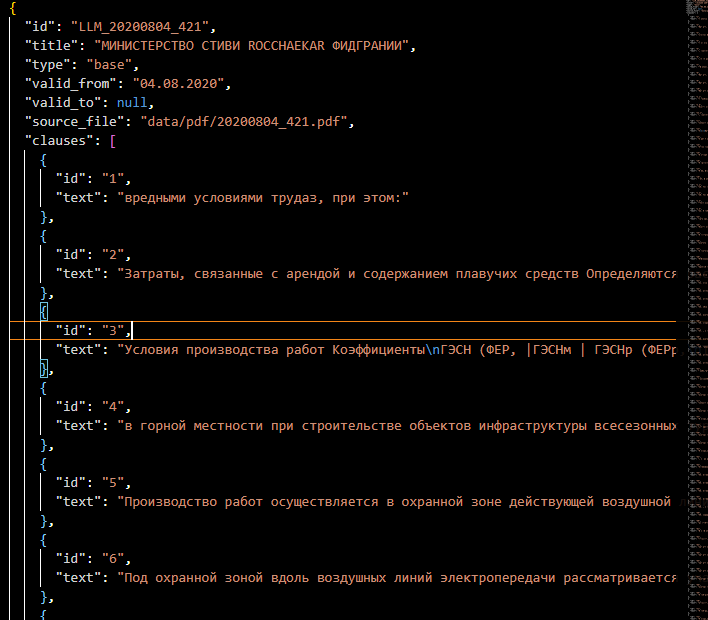
результат через ллм так же оказался ненадлежащего качества, возможно даже хуже. на данные момент перехожу на документы подготовленные в ручном режиме. в формате md

### ручная подготовка данных и их обработка

In [ ]:
# загрузка подготовленного скрипта
!wget https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/NormativeGraphBuilder.py

--2026-06-02 08:52:19--  https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/NormativeGraphBuilder.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21249 (21K) [text/plain]
Saving to: ‘NormativeGraphBuilder.py’

NormativeGraphBuild 100%[===================>]  20.75K  --.-KB/s    in 0.001s  

2026-06-02 08:52:19 (14.9 MB/s) - ‘NormativeGraphBuilder.py’ saved [21249/21249]



In [ ]:
# загрузка подготовленных вручную файлов с текстам
!wget https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20200804_pr_421.md
!wget https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20200804_pr_421_data.md
!wget https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20220707_pr_557-421.md
!wget https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20220707_pr_557-421_add.md

--2026-06-02 08:15:51--  https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20200804_pr_421.md
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3049 (3.0K) [text/plain]
Saving to: ‘minstroy_20200804_pr_421.md’

minstroy_20200804_p 100%[===================>]   2.98K  --.-KB/s    in 0s      

2026-06-02 08:15:51 (40.2 MB/s) - ‘minstroy_20200804_pr_421.md’ saved [3049/3049]

--2026-06-02 08:15:51--  https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/data/md/minstroy_20200804_pr_421_data.md
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|18

In [ ]:
import NormativeGraphBuilder
from pathlib import Path

files_content = {}
for fname in [
    "minstroy_20200804_pr_421.md",
    "minstroy_20200804_pr_421_data.md",
    "minstroy_20220707_pr_557-421.md",
    "minstroy_20220707_pr_557-421_add.md"]:
    with open(f"{fname}", "r", encoding="utf-8") as f:
        files_content[fname] = f.read()

builder = NormativeGraphBuilder.NormativeGraphBuilder()
result = builder.run("metodika_421", "estimated", files_content)
# Сохранение
out_path = Path("metodika_421_graph.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    f.write(result.model_dump_json(exclude_none=True))

print(f"✅ JSON сохранён: {out_path}")
print(f"📊 Статистика: {result.stats}")
print(f"🔗 Пример узла (изменение):\n{next((n.model_dump_json(indent=2, exclude_none=True) for n in result.nodes), None)}")

✅ JSON сохранён: metodika_421_graph.json
📊 Статистика: {'total_nodes': 449, 'types': {'clause': 434, 'order': 1, 'section': 13, 'amendment_order': 1}}
🔗 Пример узла (изменение):
{
  "id": "pr_421",
  "type": "order",
  "number": "421/пр",
  "published_at": "2020-08-04",
  "valid_from": "2020-10-05",
  "signer": {
    "position": "Министр",
    "shortname": "В.В. Якушев"
  },
  "registration": {
    "department": {
      "fullname": "МИНИСТЕРСТВО ЮСТИЦИИ РОССИЙСКОЙ ФЕДЕРАЦИИ"
    },
    "number": 59986,
    "registrated_at": "2020-09-23"
  },
  "title": "Об утверждении Методики определения сметной стоимости строительства, реконструкции, капитального ремонта, сноса объектов капитального строительства, работ по сохранению объектов культурного наследия (памятников истории и культуры) народов Российской Федерации на территории Российской Федерации",
  "text": "В соответствии с пунктом 30 статьи 1, пунктом 7.5 части 1 статьи 6, частью 3 статьи 8.3 Градостроительного кодекса Российской Федера

### Итог. Парсинг нормативных документов при помощи расширяемой библиотеки

#### Исходные данные

**Основной документ** (`methodika_421.md`):
```markdown
# МЕТОДИКА
## определения сметной стоимости...

### I. Общие положения

1. Настоящая Методика определяет единые методы...

2. Сметная стоимость строительства определяется:
   а) базисно-индексным методом;
   б) ресурсно-индексным методом;
   в) ресурсным методом.

3. При определении сметной стоимости используются:
   - сметные нормативы;
   - проектная документация.

...

### XII. Особенности реставрации

193. При определении сметной стоимости работ по сохранению объектов культурного наследия...

194. Накладные расходы при реставрации составляют 85% от оплаты труда...
```

**Поправки** (`amendments_421.md`):
```markdown
1. В пункте 2:
   а) подпункт «а» изложить в следующей редакции:
   «а) базисно-индексным методом — с применением единичных расценок;»;
   б) дополнить подпунктом «в.1» следующего содержания:
   «в.1) ресурсно-индексным методом — с использованием ФГИС ЦС;».

7. В пункте 10 слова «базисно-индексным» заменить словами «ресурсно-индексным».

11. В пункте 194:
   а) слова «85%» заменить словами «85% в текущем уровне цен»;
   б) дополнить абзацем следующего содержания:
   «Расходы на эксплуатацию машин определяются в размере 10% от оплаты труда.»
```

### Результат парсинга

**DocumentGraph** (упрощённо):
```json
{
  "nodes": {
    "doc:methodika_421": {
      "type": "document",
      "title": "Методика определения сметной стоимости..."
    },
    "sec:I": {
      "type": "section",
      "title": "I. Общие положения",
      "roman_number": "I"
    },
    "point:2": {
      "type": "point",
      "number": "2",
      "text": "Сметная стоимость строительства определяется:\nа) базисно-индексным методом;\nб) ресурсно-индексным методом;\nв) ресурсным методом.",
      "section_id": "sec:I"
    },
    "point:194": {
      "type": "point",
      "number": "194",
      "text": "Накладные расходы при реставрации составляют 85% от оплаты труда...",
      "section_id": "sec:XII"
    },
    "amend:7": {
      "type": "amendment",
      "amendment_number": "7",
      "action": "replace",
      "target_point_ids": ["point:10"],
      "amendment_date": "2024-03-15"
    },
    "repl:7_1": {
      "type": "replacement",
      "old_text": "базисно-индексным",
      "new_text": "ресурсно-индексным",
      "amendment_id": "7"
    }
  },
  "edges": [
    {"source_id": "doc:methodika_421", "target_id": "sec:I", "type": "contains"},
    {"source_id": "sec:I", "target_id": "point:2", "type": "contains"},
    {"source_id": "amend:7", "target_id": "point:10", "type": "amends"},
    {"source_id": "repl:7_1", "target_id": "point:10", "type": "amends"}
  ]
}
```

### Этап 2: Загрузка готового графа

In [1]:
import json
import requests
from pathlib import Path

# Скачиваем готовый граф из GitHub
GRAPH_URL = "https://raw.githubusercontent.com/AleksandrMac/learning/refs/heads/main/ai/practic/2/output/graph_v2.json"

# Или используем локальный файл
GRAPH_PATH = "output/graph_v2.json"

def load_graph_from_github(url: str) -> dict:
    """Загружает граф из GitHub."""
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"❌ Ошибка загрузки из GitHub: {e}")
        print("Используем тестовый граф...")
        return create_demo_graph()

def create_demo_graph() -> dict:
    """Создаёт демо-граф для тестирования."""
    return {
        "nodes": {
            "doc:methodika_421": {
                "id": "doc:methodika_421",
                "type": "document",
                "title": "Методика определения сметной стоимости строительства",
                "version": "421-пр",
                "metadata": {}
            },
            "sec:I": {
                "id": "sec:I",
                "type": "section",
                "title": "I. Общие положения",
                "roman_number": "I",
                "text": "Общие положения методики определения сметной стоимости.",
                "metadata": {}
            },
            "sec:XII": {
                "id": "sec:XII",
                "type": "section",
                "title": "XII. Особенности реставрации",
                "roman_number": "XII",
                "text": "Особенности определения сметной стоимости работ по сохранению объектов культурного наследия.",
                "metadata": {}
            },
            "point:2": {
                "id": "point:2",
                "type": "point",
                "number": "2",
                "level": 1,
                "text": "Сметная стоимость строительства определяется:\nа) базисно-индексным методом;\nб) ресурсно-индексным методом;\nв) ресурсным методом.",
                "section_id": "sec:I",
                "metadata": {}
            },
            "point:10": {
                "id": "point:10",
                "type": "point",
                "number": "10",
                "level": 1,
                "text": "При определении сметной стоимости базисно-индексным методом используются единичные расценки.",
                "section_id": "sec:I",
                "metadata": {}
            },
            "point:194": {
                "id": "point:194",
                "type": "point",
                "number": "194",
                "level": 1,
                "text": "Накладные расходы при определении сметной стоимости ремонтно-реставрационных работ составляют 85% от оплаты труда, учитываемой в прямых затратах.",
                "section_id": "sec:XII",
                "metadata": {}
            },
            "amend:7": {
                "id": "amend:7",
                "type": "amendment",
                "amendment_number": "7",
                "action": "replace",
                "target_point_ids": ["point:10"],
                "amendment_date": "2024-03-15",
                "source_text": "В пункте 10 слова «базисно-индексным» заменить словами «ресурсно-индексным».",
                "metadata": {}
            },
            "repl:7_1": {
                "id": "repl:7_1",
                "type": "replacement",
                "old_text": "базисно-индексным",
                "new_text": "ресурсно-индексным",
                "amendment_id": "7",
                "metadata": {}
            }
        },
        "edges": [
            {"source_id": "doc:methodika_421", "target_id": "sec:I", "type": "contains", "metadata": {}},
            {"source_id": "doc:methodika_421", "target_id": "sec:XII", "type": "contains", "metadata": {}},
            {"source_id": "sec:I", "target_id": "point:2", "type": "contains", "metadata": {}},
            {"source_id": "sec:I", "target_id": "point:10", "type": "contains", "metadata": {}},
            {"source_id": "sec:XII", "target_id": "point:194", "type": "contains", "metadata": {}},
            {"source_id": "amend:7", "target_id": "point:10", "type": "amends", "metadata": {}},
            {"source_id": "repl:7_1", "target_id": "point:10", "type": "amends", "metadata": {}}
        ],
        "metadata": {
            "created_at": "2024-06-29",
            "version": "2.0"
        }
    }

# Загружаем граф
print("📥 Загрузка графа...")
graph_data = load_graph_from_github(GRAPH_URL)
print(f"✅ Загружено {len(graph_data['nodes'])} узлов и {len(graph_data['edges'])} рёбер")

📥 Загрузка графа...
✅ Загружено 952 узлов и 1014 рёбер


### Этап 3: Инициализация DocumentGraph

In [2]:
from enum import Enum
from typing import Optional, List, Dict, Any
from datetime import datetime
from pydantic import BaseModel, Field


class NodeType(str, Enum):
    DOCUMENT = 'document'
    SECTION = 'section'
    POINT = 'point'
    PARAGRAPH = 'paragraph'
    FORMULA = 'formula'
    DEFINITION = 'definition'
    AMENDMENT = 'amendment'
    REPLACEMENT = 'replacement'


class EdgeType(str, Enum):
    CONTAINS = 'contains'
    AMENDS = 'amends'
    REFERENCES = 'references'
    SUPERSEDES = 'supersedes'
    DEFINES = 'defines'
    USES_TERM = 'uses_term'


class GraphNode(BaseModel):
    id: str
    type: NodeType
    number: Optional[str] = None
    level: Optional[int] = None
    text: Optional[str] = None
    title: Optional[str] = None
    metadata: Dict[str, Any] = Field(default_factory=dict)
    created_at: datetime = Field(default_factory=datetime.now)

    class Config:
        frozen = False


class DocumentNode(GraphNode):
    type: NodeType = NodeType.DOCUMENT
    title: str
    version: Optional[str] = None


class SectionNode(GraphNode):
    type: NodeType = NodeType.SECTION
    title: str
    roman_number: Optional[str] = None


class PointNode(GraphNode):
    type: NodeType = NodeType.POINT
    number: str
    level: int = 1
    text: str = ''


class AmendmentNode(GraphNode):
    type: NodeType = NodeType.AMENDMENT
    amendment_number: str
    action: str
    target_point_ids: List[str] = Field(default_factory=list)
    amendment_date: Optional[str] = None


class ReplacementNode(GraphNode):
    type: NodeType = NodeType.REPLACEMENT
    old_text: Optional[str] = None
    new_text: Optional[str] = None
    amendment_id: str


class GraphEdge(BaseModel):
    source_id: str
    target_id: str
    type: EdgeType
    metadata: Dict[str, Any] = Field(default_factory=dict)

    class Config:
        frozen = False


class DocumentGraph(BaseModel):
    nodes: Dict[str, GraphNode] = Field(default_factory=dict)
    edges: List[GraphEdge] = Field(default_factory=list)
    metadata: Dict[str, Any] = Field(default_factory=dict)

    def add_node(self, node: GraphNode) -> None:
        self.nodes[node.id] = node

    def add_edge(self, edge: GraphEdge) -> None:
        if edge.source_id not in self.nodes:
            raise ValueError(f"Source node {edge.source_id} not found")
        if edge.target_id not in self.nodes:
            raise ValueError(f"Target node {edge.target_id} not found")
        self.edges.append(edge)

    def get_node(self, node_id: str) -> Optional[GraphNode]:
        return self.nodes.get(node_id)

    def get_edges_from(self, node_id: str, edge_type: Optional[EdgeType] = None) -> List[GraphEdge]:
        result = []
        for edge in self.edges:
            if edge.source_id == node_id:
                if edge_type is None or edge.type == edge_type:
                    result.append(edge)
        return result

    def get_edges_to(self, node_id: str, edge_type: Optional[EdgeType] = None) -> List[GraphEdge]:
        result = []
        for edge in self.edges:
            if edge.target_id == node_id:
                if edge_type is None or edge.type == edge_type:
                    result.append(edge)
        return result

    def get_children(self, node_id: str) -> List[GraphNode]:
        edges = self.get_edges_from(node_id, EdgeType.CONTAINS)
        return [self.nodes[e.target_id] for e in edges if e.target_id in self.nodes]

    def get_parent(self, node_id: str) -> Optional[GraphNode]:
        edges = self.get_edges_to(node_id, EdgeType.CONTAINS)
        if edges:
            return self.nodes.get(edges[0].source_id)
        return None

    def get_all_text_nodes(self) -> List[GraphNode]:
        text_nodes = []
        for node in self.nodes.values():
            if node.type in [NodeType.POINT, NodeType.PARAGRAPH, NodeType.SECTION]:
                if node.text:
                    text_nodes.append(node)
        return text_nodes

    def get_amendments_for_point(self, point_id: str) -> List[AmendmentNode]:
        amendments = []
        for edge in self.get_edges_to(point_id, EdgeType.AMENDS):
            amendment_node = self.nodes.get(edge.source_id)
            if amendment_node and amendment_node.type == NodeType.AMENDMENT:
                amendments.append(amendment_node)
        return amendments

    def get_point_history(self, point_id: str) -> List[Dict[str, Any]]:
        history = []
        amendments = self.get_amendments_for_point(point_id)

        for amendment in amendments:
            # Ищем замены для этой поправки
            for edge in self.get_edges_to(point_id, EdgeType.AMENDS):
                replacement_node = self.nodes.get(edge.source_id)
                if replacement_node and replacement_node.type == NodeType.REPLACEMENT:
                    if replacement_node.amendment_id == amendment.amendment_number:
                        history.append({
                            'amendment_id': amendment.amendment_number,
                            'action': amendment.action,
                            'old_text': replacement_node.old_text,
                            'new_text': replacement_node.new_text,
                            'date': amendment.amendment_date,
                        })

        return sorted(history, key=lambda x: x.get('date', ''), reverse=True)

    def get_full_context(self, point_id: str) -> Dict[str, Any]:
        node = self.get_node(point_id)
        if not node:
            return {'error': 'Point not found'}

        parent = self.get_parent(point_id)
        history = self.get_point_history(point_id)

        return {
            'node': node,
            'section': parent.title if parent else None,
            'history': history,
        }

/tmp/ipykernel_3478/2903908180.py:27: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphNode(BaseModel):
/tmp/ipykernel_3478/2903908180.py:75: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphEdge(BaseModel):


In [3]:
# Создаём граф из JSON
def build_graph_from_json(data: dict) -> DocumentGraph:
    """Строит DocumentGraph из JSON-словаря."""
    graph = DocumentGraph()

    # Создаём узлы
    node_class_map = {
        NodeType.DOCUMENT: DocumentNode,
        NodeType.SECTION: SectionNode,
        NodeType.POINT: PointNode,
        NodeType.AMENDMENT: AmendmentNode,
        NodeType.REPLACEMENT: ReplacementNode,
    }

    for node_id, node_data in data['nodes'].items():
        node_type = NodeType(node_data['type'])
        node_class = node_class_map.get(node_type, GraphNode)
        node = node_class(**node_data)
        graph.add_node(node)

    # Создаём рёбра
    for edge_data in data['edges']:
        edge = GraphEdge(**edge_data)
        graph.add_edge(edge)

    return graph

# Инициализируем граф
print("🏗️ Построение DocumentGraph...")
doc_graph = build_graph_from_json(graph_data)
print(f"✅ Граф построен: {len(doc_graph.nodes)} узлов, {len(doc_graph.edges)} рёбер")

# Показываем статистику
node_types = {}
for node in doc_graph.nodes.values():
    node_types[node.type.value] = node_types.get(node.type.value, 0) + 1

print("\n📊 Статистика узлов:")
for node_type, count in sorted(node_types.items()):
    print(f"  - {node_type}: {count}")

🏗️ Построение DocumentGraph...
✅ Граф построен: 952 узлов, 1014 рёбер

📊 Статистика узлов:
  - amendment: 127
  - document: 1
  - paragraph: 416
  - point: 354
  - replacement: 43
  - section: 11


### Этап 4: Инициализация GraphRetriever

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np


class GraphRetriever:
    """Гибридный Retriever для DocumentGraph."""

    def __init__(
        self,
        graph: DocumentGraph,
        model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        device: str = "cpu"
    ):
        print(f"🤖 Загрузка модели эмбеддингов: {model_name}")
        self.graph = graph
        self.model = SentenceTransformer(model_name, device=device)

        self.node_ids: List[str] = []
        self.node_texts: List[str] = []
        self.node_embeddings: np.ndarray = None

        self._build_vector_index()

    def _build_vector_index(self):
        """Индексирует текстовые узлы графа."""
        text_nodes = self.graph.get_all_text_nodes()

        self.node_ids = [node.id for node in text_nodes]
        self.node_texts = [node.text for node in text_nodes]

        if self.node_texts:
            print(f"📚 Индексация {len(self.node_texts)} текстовых узлов...")
            self.node_embeddings = self.model.encode(
                self.node_texts,
                convert_to_numpy=True,
                show_progress_bar=False,
                device='cpu'
            )
            print(f"✅ Векторный индекс построен: {self.node_embeddings.shape}")

    def semantic_search(self, query: str, top_k: int = 3, verbose: bool = False) -> List[Dict[str, Any]]:
        """Находит узлы по смыслу вопроса."""
        if self.node_embeddings is None:
            return []

        if verbose:
            print(f"\n🔍 Семантический поиск: '{query}'")

        query_emb = self.model.encode([query], convert_to_numpy=True, device='cpu')
        similarities = np.dot(self.node_embeddings, query_emb.T).flatten()
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            node_id = self.node_ids[idx]
            node = self.graph.get_node(node_id)
            parent = self.graph.get_parent(node_id)

            result = {
                'node': node,
                'score': float(similarities[idx]),
                'section': parent.title if parent else None,
            }
            results.append(result)

            if verbose:
                print(f"  [{result['score']:.3f}] {node.type.value.upper()} {node.number}: {node.text[:100]}...")

        return results

    def get_point_history(self, point_id: str) -> List[Dict[str, Any]]:
        """Возвращает историю изменений пункта."""
        return self.graph.get_point_history(point_id)

    def retrieve_context(self, query: str, top_k: int = 3, include_history: bool = False, verbose: bool = False) -> str:
        """Формирует финальный контекст для промпта LLM."""
        results = self.semantic_search(query, top_k=top_k, verbose=verbose)

        context_parts = []
        for res in results:
            node = res['node']

            part = f"[{node.type.value.upper()} {node.number}]"
            if res.get('section'):
                part += f" (Раздел: {res['section']})"
            part += f"\n{node.text}\n"

            if include_history:
                history = self.get_point_history(node.id)
                if history:
                    part += "\n📜 История изменений:\n"
                    for h in history:
                        part += f"  - Поправка №{h['amendment_id']} ({h['action']}): "
                        if h.get('old_text'):
                            part += f"было «{h['old_text']}» → стало «{h['new_text']}»\n"
                        else:
                            part += f"«{h['new_text']}»\n"

            context_parts.append(part)

        return "\n---\n".join(context_parts)

In [11]:
# Инициализируем Retriever
print("\n🚀 Инициализация GraphRetriever...")
retrieverV1 = GraphRetriever(doc_graph)
print("✅ Retriever готов к работе!")


🚀 Инициализация GraphRetriever...
🤖 Загрузка модели эмбеддингов: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

📚 Индексация 734 текстовых узлов...
✅ Векторный индекс построен: (734, 384)
✅ Retriever готов к работе!


### Этап 5: Отладка запросов с трассировкой

In [13]:
# Тестовые запросы
test_queries = [
    "Как определяются накладные расходы на реставрацию?",
    "Что такое базисно-индексный метод?",
    "Какие методы определения сметной стоимости существуют?",
    "пункт 19",
]

print("=" * 80)
print("🧪 ТЕСТИРОВАНИЕ ЗАПРОСОВ С ТРАССИРОВКОЙ")
print("=" * 80)

for i, query in enumerate(test_queries, 1):
    print(f"\n{'='*80}")
    print(f"📝 ЗАПРОС #{i}: {query}")
    print(f"{'='*80}")

    # Шаг 1: Семантический поиск
    print("\n🔍 ШАГ 1: Семантический поиск (векторный)")
    results = retrieverV1.semantic_search(query, top_k=2, verbose=True)

    # Шаг 2: Графовое обогащение
    print("\n🕸️ ШАГ 2: Графовое обогащение (контекст)")
    for res in results:
        node = res['node']
        context = retrieverV1.graph.get_full_context(node.id)
        print(f"  📍 {node.type.value.upper()} {node.number}")
        if context.get('section'):
            print(f"     Раздел: {context['section']}")
        if context.get('history'):
            print(f"     📜 История изменений: {len(context['history'])} поправок")
            for h in context['history']:
                print(f"        - Поправка №{h['amendment_id']}: {h['old_text']} → {h['new_text']}")

    # Шаг 3: Формирование финального контекста
    print("\n📄 ШАГ 3: Формирование контекста для LLM")
    final_context = retrieverV1.retrieve_context(query, top_k=2, include_history=True, verbose=False)
    print(final_context)

    print(f"\n{'─'*80}")

print("\n✅ Тестирование завершено!")

🧪 ТЕСТИРОВАНИЕ ЗАПРОСОВ С ТРАССИРОВКОЙ

📝 ЗАПРОС #1: Как определяются накладные расходы на реставрацию?

🔍 ШАГ 1: Семантический поиск (векторный)

🔍 Семантический поиск: 'Как определяются накладные расходы на реставрацию?'
  [10.557] PARAGRAPH 1: Сметная стоимость строительства определяется:...
  [10.486] POINT 71: В случае, если проектной документацией предусмотрено применение годных для повторного использования ...

🕸️ ШАГ 2: Графовое обогащение (контекст)
  📍 PARAGRAPH 1
  📍 POINT 71
     Раздел: Локальные сметные расчеты (сметы)

📄 ШАГ 3: Формирование контекста для LLM
[PARAGRAPH 1]
Сметная стоимость строительства определяется:

---
[POINT 71] (Раздел: Локальные сметные расчеты (сметы))
В случае, если проектной документацией предусмотрено применение годных для повторного использования (ранее использованных один и более раз) материальных ресурсов, их стоимость в текущем уровне цен определяется заказчиком с учетом оценки их возможного повторного использования.


─────────────────────

по результатам тестирования что векторный поиск работает корректно, но с нюансами. Например:
1. на первый и третий вопрос выдается только вводная часть пункта;
1. при запросе определения базисно-индексного метода во втором вопросе, нет валидной информации, потому что документ не расскрывает этого определения;
1. 4 вопросе по поиску пункта 194. ближайшее сходство показывает текст содержащий упомининание слова пункт, в результате ответ не имеет полезного эффекта.

в качестве решения можно строить векторное представления всего пункта, а не отдельной его составляющей. а так же добавить векторное предствление текстового наименования пункта, подпункта, абзаца.

#### модификация ретривера

In [8]:
# @title
import numpy as np
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Any, Optional, Tuple

class GraphRetrieverV2:
    """
    GraphRetriever v2: двойное векторное представление.

    🔑 Два индекса:
    1. TEXT_INDEX — полный текст узла (с подпунктами и абзацами)
    2. ADDRESS_INDEX — текстовый адрес ("пункт 194", "подпункт 41.б")

    🔑 Гибридный поиск:
    - Семантический: "Как считать накладные расходы?" → TEXT_INDEX
    - Адресный: "пункт 194" → ADDRESS_INDEX
    - Комбинированный: оба индекса → взвешенный результат
    """

    def __init__(
        self,
        graph: DocumentGraph,
        model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        device: str = "cpu"
    ):
        print(f"🤖 Загрузка модели: {model_name}")
        self.graph = graph
        self.model = SentenceTransformer(model_name, device=device)

        # ═══════════════════════════════════════════════════
        # Индекс 1: Полный текст (узел + дети)
        # ═══════════════════════════════════════════════════
        self.text_ids: List[str] = []
        self.text_contents: List[str] = []
        self.text_embeddings: Optional[np.ndarray] = None

        # ═══════════════════════════════════════════════════
        # Индекс 2: Текстовые адреса
        # ═══════════════════════════════════════════════════
        self.addr_ids: List[str] = []
        self.addr_labels: List[str] = []
        self.addr_embeddings: Optional[np.ndarray] = None

        self._build_indices()

    # ═══════════════════════════════════════════════════════
    # 🔧 ПОСТРОЕНИЕ ИНДЕКСОВ
    # ═══════════════════════════════════════════════════════

    def _build_indices(self):
        """Строит оба векторных индекса."""
        self._build_text_index()
        self._build_address_index()

    def _get_full_text(self, node: GraphNode, depth: int = 0) -> str:
        """
        Рекурсивно собирает полный текст узла и всех его детей.

        Пример для пункта 195:
        "При определении сметной стоимости...
         а) накладных расходов в размере 21,9%;
         б) накладных расходов в размере 85%;
         в) сметной прибыли в размере 8%."
        """
        parts = []

        # 1. Собственный текст узла
        if node.text:
            parts.append(node.text)
        elif node.title:
            parts.append(node.title)

        # 2. Рекурсивно добавляем текст детей (CONTAINS)
        children = self.graph.get_children(node.id)

        # Сортируем детей по номеру для стабильного порядка
        children_sorted = sorted(children, key=lambda c: c.number or '0')

        for child in children_sorted:
            child_text = self._get_full_text(child, depth + 1)
            if child_text:
                # Добавляем отступ для читаемости
                prefix = "  " * depth
                if child.type == NodeType.POINT and child.number:
                    # Подпункт: "а) текст"
                    parts.append(f"{prefix}{child.number}) {child_text}")
                elif child.type == NodeType.PARAGRAPH and child.number:
                    # Абзац: просто текст
                    parts.append(f"{prefix}{child_text}")
                else:
                    parts.append(f"{prefix}{child_text}")

        return "\n".join(parts).strip()

    def _get_node_address(self, node: GraphNode) -> str:
        """
        Генерирует текстовый адрес узла.

        Примеры:
        - PointNode(194) → "пункт 194"
        - PointNode(б, level=2, parent=point:195) → "подпункт 195.б"
        - ParagraphNode(1, parent=point:10) → "абзац первый пункта 10"
        - SectionNode(I) → "раздел I"
        """
        ordinal_map = {
            '1': 'первый', '2': 'второй', '3': 'третий',
            '4': 'четвёртый', '5': 'пятый', '6': 'шестой',
            '7': 'седьмой', '8': 'восьмой', '9': 'девятый', '10': 'десятый',
        }

        if node.type == NodeType.SECTION:
            return f"раздел {node.roman_number or node.number or ''}".strip()

        if node.type == NodeType.POINT:
            # Проверяем уровень
            if node.level and node.level >= 2:
                # Подпункт: "подпункт 195.б"
                parent = self.graph.get_parent(node.id)
                parent_num = parent.number if parent else ''
                return f"подпункт {parent_num}.{node.number}"
            else:
                # Пункт: "пункт 194"
                return f"пункт {node.number}"

        if node.type == NodeType.PARAGRAPH:
            # Абзац: "абзац первый пункта 10"
            parent = self.graph.get_parent(node.id)
            parent_label = f" пункта {parent.number}" if parent and parent.number else ""
            ordinal = ordinal_map.get(node.number, node.number)
            return f"абзац {ordinal}{parent_label}"

        # Fallback
        return f"{node.type.value} {node.number or node.id}"

    def _build_text_index(self):
        """Строит векторный индекс полных текстов."""
        print("📚 Построение текстового индекса...")

        self.text_ids = []
        self.text_contents = []

        # Индексируем только узлы верхнего уровня (sections и top-level points)
        # Подпункты и абзацы уже включены в текст родителя
        for node in self.graph.nodes.values():
            if node.type in [NodeType.POINT, NodeType.SECTION]:
                # Для Point: только если это верхний уровень (level=1 или нет level)
                if node.type == NodeType.POINT and node.level and node.level > 1:
                    continue

                full_text = self._get_full_text(node)
                if full_text:
                    self.text_ids.append(node.id)
                    self.text_contents.append(full_text)

        if self.text_contents:
            self.text_embeddings = self.model.encode(
                self.text_contents,
                convert_to_numpy=True,
                show_progress_bar=False,
                device='cpu'
            )
            print(f"  ✅ Текстовый индекс: {len(self.text_ids)} узлов, "
                  f"размерность {self.text_embeddings.shape}")
        else:
            print("  ⚠️ Нет текстов для индексации")

    def _build_address_index(self):
        """Строит векторный индекс адресов."""
        print("📍 Построение адресного индекса...")

        self.addr_ids = []
        self.addr_labels = []

        # Индексируем ВСЕ текстовые узлы (включая подпункты и абзацы)
        for node in self.graph.nodes.values():
            if node.type in [NodeType.POINT, NodeType.PARAGRAPH, NodeType.SECTION]:
                address = self._get_node_address(node)
                self.addr_ids.append(node.id)
                self.addr_labels.append(address)

        if self.addr_labels:
            self.addr_embeddings = self.model.encode(
                self.addr_labels,
                convert_to_numpy=True,
                show_progress_bar=False,
                device='cpu'
            )
            print(f"  ✅ Адресный индекс: {len(self.addr_ids)} адресов, "
                  f"размерность {self.addr_embeddings.shape}")
        else:
            print("  ⚠️ Нет адресов для индексации")

    # ═══════════════════════════════════════════════════════
    # 🔍 ПОИСК
    # ═══════════════════════════════════════════════════════

    def semantic_search(
        self,
        query: str,
        top_k: int = 3,
        verbose: bool = False
    ) -> List[Dict[str, Any]]:
        """Семантический поиск по полному тексту."""
        if self.text_embeddings is None:
            return []

        if verbose:
            print(f"\n🔍 Семантический поиск: '{query}'")

        query_emb = self.model.encode([query], convert_to_numpy=True, device='cpu')
        similarities = np.dot(self.text_embeddings, query_emb.T).flatten()
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            node_id = self.text_ids[idx]
            node = self.graph.get_node(node_id)
            parent = self.graph.get_parent(node_id)

            result = {
                'node': node,
                'score': float(similarities[idx]),
                'section': parent.title if parent else None,
                'match_type': 'text',
                'full_text': self.text_contents[idx],
            }
            results.append(result)

            if verbose:
                addr = self._get_node_address(node)
                print(f"  [{result['score']:.3f}] {addr}: {self.text_contents[idx][:120]}...")

        return results

    def address_search(
        self,
        query: str,
        top_k: int = 3,
        verbose: bool = False
    ) -> List[Dict[str, Any]]:
        """Поиск по текстовому адресу ("пункт 194", "подпункт 10.б")."""
        if self.addr_embeddings is None:
            return []

        if verbose:
            print(f"\n📍 Адресный поиск: '{query}'")

        query_emb = self.model.encode([query], convert_to_numpy=True, device='cpu')
        similarities = np.dot(self.addr_embeddings, query_emb.T).flatten()
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            node_id = self.addr_ids[idx]
            node = self.graph.get_node(node_id)
            parent = self.graph.get_parent(node_id)

            result = {
                'node': node,
                'score': float(similarities[idx]),
                'address': self.addr_labels[idx],
                'section': parent.title if parent else None,
                'match_type': 'address',
                'full_text': self._get_full_text(node),
            }
            results.append(result)

            if verbose:
                print(f"  [{result['score']:.3f}] {self.addr_labels[idx]}")

        return results

    def hybrid_search(
        self,
        query: str,
        top_k: int = 3,
        text_weight: float = 0.6,
        addr_weight: float = 0.4,
        verbose: bool = False
    ) -> List[Dict[str, Any]]:
        """
        🔑 Гибридный поиск: комбинация текстового и адресного.

        Args:
            query: Вопрос пользователя
            top_k: Количество результатов
            text_weight: Вес текстового поиска (0.0 - 1.0)
            addr_weight: Вес адресного поиска (0.0 - 1.0)
        """
        if verbose:
            print(f"\n🔀 Гибридный поиск: '{query}' (text={text_weight}, addr={addr_weight})")

        # 1. Семантический поиск
        text_results = self.semantic_search(query, top_k=top_k * 2, verbose=False)

        # 2. Адресный поиск
        addr_results = self.address_search(query, top_k=top_k * 2, verbose=False)

        # 3. Объединяем результаты с весами
        combined_scores: Dict[str, float] = {}
        result_map: Dict[str, Dict[str, Any]] = {}

        for res in text_results:
            node_id = res['node'].id
            score = res['score'] * text_weight
            combined_scores[node_id] = combined_scores.get(node_id, 0) + score
            if node_id not in result_map:
                result_map[node_id] = res

        for res in addr_results:
            node_id = res['node'].id
            score = res['score'] * addr_weight
            combined_scores[node_id] = combined_scores.get(node_id, 0) + score
            if node_id not in result_map:
                result_map[node_id] = res

        # 4. Сортируем по комбинированному score
        sorted_ids = sorted(combined_scores.keys(), key=lambda x: combined_scores[x], reverse=True)[:top_k]

        results = []
        for node_id in sorted_ids:
            res = result_map[node_id].copy()
            res['score'] = combined_scores[node_id]
            res['match_type'] = 'hybrid'
            results.append(res)

            if verbose:
                addr = self._get_node_address(res['node'])
                print(f"  [{res['score']:.3f}] {addr}: {res.get('full_text', '')[:120]}...")

        return results

    # ═══════════════════════════════════════════════════════
    # 📄 КОНТЕКСТ ДЛЯ LLM
    # ═══════════════════════════════════════════════════════

    def retrieve_context(
        self,
        query: str,
        top_k: int = 3,
        include_history: bool = True,
        search_mode: str = 'hybrid',
        verbose: bool = False
    ) -> str:
        """
        Формирует финальный контекст для LLM.

        Args:
            query: Вопрос пользователя
            top_k: Количество результатов
            include_history: Включать ли историю изменений
            search_mode: 'semantic', 'address', 'hybrid'
        """
        # Выбираем режим поиска
        if search_mode == 'semantic':
            results = self.semantic_search(query, top_k=top_k, verbose=verbose)
        elif search_mode == 'address':
            results = self.address_search(query, top_k=top_k, verbose=verbose)
        else:
            results = self.hybrid_search(query, top_k=top_k, verbose=verbose)

        # Формируем контекст
        context_parts = []
        for i, res in enumerate(results, 1):
            node = res['node']
            addr = self._get_node_address(node)

            part = f"[{i}] {addr}"
            if res.get('section'):
                part += f" | Раздел: {res['section']}"
            part += f" (релевантность: {res['score']:.3f})"
            part += f"\n{res.get('full_text', node.text or '')}\n"

            # История изменений
            if include_history and node.type == NodeType.POINT:
                history = self.graph.get_point_history(node.id)
                if history:
                    part += "\n📜 История изменений:\n"
                    for h in history:
                        part += f"  • Поправка №{h['amendment_id']} ({h['action']}): "
                        if h.get('old_text'):
                            part += f"«{h['old_text']}» → «{h['new_text']}»\n"
                        else:
                            part += f"«{h.get('new_text', '')}»\n"

            context_parts.append(part)

        return "\n" + "=" * 60 + "\n".join(context_parts)

    # ═══════════════════════════════════════════════════════
    # 📊 ДИАГНОСТИКА
    # ═══════════════════════════════════════════════════════

    def show_index_stats(self):
        """Показывает статистику индексов."""
        print("\n📊 СТАТИСТИКА ИНДЕКСОВ")
        print("=" * 60)

        print(f"\n📚 Текстовый индекс:")
        print(f"  Узлов: {len(self.text_ids)}")
        if self.text_embeddings is not None:
            print(f"  Размерность: {self.text_embeddings.shape}")
            avg_len = np.mean([len(t) for t in self.text_contents])
            print(f"  Средняя длина текста: {avg_len:.0f} символов")

        print(f"\n📍 Адресный индекс:")
        print(f"  Адресов: {len(self.addr_ids)}")
        if self.addr_embeddings is not None:
            print(f"  Размерность: {self.addr_embeddings.shape}")
            # Показываем примеры адресов
            print(f"  Примеры:")
            for addr in self.addr_labels[:5]:
                print(f"    - {addr}")
            if len(self.addr_labels) > 5:
                print(f"    ... и ещё {len(self.addr_labels) - 5}")

### тестриование ретривераV2

In [16]:
# ═══════════════════════════════════════════════════════
# 🔧 Инициализация v2
# ═══════════════════════════════════════════════════════

print("=" * 60)
print("🚀 ИНИЦИАЛИЗАЦИЯ GraphRetrieverV2")
print("=" * 60)

retrieverv2 = GraphRetrieverV2(doc_graph)
retrieverv2.show_index_stats()


# ═══════════════════════════════════════════════════════
# 🧪 ТЕСТ 1: Семантический поиск
# ═══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("🧪 ТЕСТ 1: Семантический поиск")
print("=" * 60)

results = retrieverv2.semantic_search(
    "Как определяются накладные расходы на реставрацию?",
    top_k=3,
    verbose=True
)

results = retrieverv2.semantic_search(
    "Как определяется стоимость строительства?",
    top_k=3,
    verbose=True
)


# ═══════════════════════════════════════════════════════
# 🧪 ТЕСТ 2: Адресный поиск
# ═══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("🧪 ТЕСТ 2: Адресный поиск")
print("=" * 60)

# Ищем по точному адресу
address_queries = [
    "пункт 19",
    "подпункт 10.б",
    "абзац первый пункта 10",
    "раздел XII",
]

for q in address_queries:
    results = retrieverv2.address_search(q, top_k=2, verbose=True)
    print()


# ═══════════════════════════════════════════════════════
# 🧪 ТЕСТ 3: Гибридный поиск
# ═══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("🧪 ТЕСТ 3: Гибридный поиск")
print("=" * 60)

hybrid_queries = [
    "какими методами определяется цена в пункте 10",
    "пункт 2 методы определения сметной стоимости",
]

for q in hybrid_queries:
    context = retrieverv2.retrieve_context(
        q,
        top_k=2,
        include_history=True,
        search_mode='hybrid',
        verbose=True
    )
    print(f"\n📄 Контекст для: '{q}'")
    print(context)


# ═══════════════════════════════════════════════════════
# 🧪 ТЕСТ 4: Трассировка полного запроса
# ═══════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("🧪 ТЕСТ 4: ПОЛНАЯ ТРАССИРОВКА")
print("=" * 60)

query = "Какие методы определения сметной стоимости существуют?"

print(f"\n❓ Запрос: {query}\n")

# Шаг 1: Текстовый поиск
print("━━━ ШАГ 1: Семантический поиск (TEXT_INDEX) ━━━")
text_results = retrieverv2.semantic_search(query, top_k=3, verbose=True)

# Шаг 2: Адресный поиск
print("\n━━━ ШАГ 2: Адресный поиск (ADDRESS_INDEX) ━━━")
addr_results = retrieverv2.address_search(query, top_k=3, verbose=True)

# Шаг 3: Гибридный результат
print("\n━━━ ШАГ 3: Гибридный результат ━━━")
hybrid_results = retrieverv2.hybrid_search(query, top_k=3, verbose=True)

# Шаг 4: Финальный контекст для LLM
print("\n━━━ ШАГ 4: Финальный контекст для LLM ━━━")
final_context = retrieverv2.retrieve_context(
    query,
    top_k=3,
    include_history=True,
    search_mode='hybrid'
)
print(final_context)

🚀 ИНИЦИАЛИЗАЦИЯ GraphRetrieverV2
🤖 Загрузка модели: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

📚 Построение текстового индекса...
  ✅ Текстовый индекс: 200 узлов, размерность (200, 384)
📍 Построение адресного индекса...
  ✅ Адресный индекс: 781 адресов, размерность (781, 384)

📊 СТАТИСТИКА ИНДЕКСОВ

📚 Текстовый индекс:
  Узлов: 200
  Размерность: (200, 384)
  Средняя длина текста: 2321 символов

📍 Адресный индекс:
  Адресов: 781
  Размерность: (781, 384)
  Примеры:
    - раздел I
    - пункт 1
    - абзац первый пункта 1
    - пункт 2
    - абзац первый пункта 2
    ... и ещё 776

🧪 ТЕСТ 1: Семантический поиск

🔍 Семантический поиск: 'Как определяются накладные расходы на реставрацию?'
  [9.552] пункт 71: В случае, если проектной документацией предусмотрено применение годных для повторного использования (ранее использованны...
  [7.975] пункт 5: В сметной стоимости строительства учитываются затраты, подлежащие определению на этапе архитектурно-строительного проект...
  [7.885] пункт 4: Сметная стоимость строительства определяется сметой на строительство, реконструкцию, капитальн

### Визуализация графа (опционально)

📊 Визуализация графа...


/tmp/ipykernel_3478/796153108.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


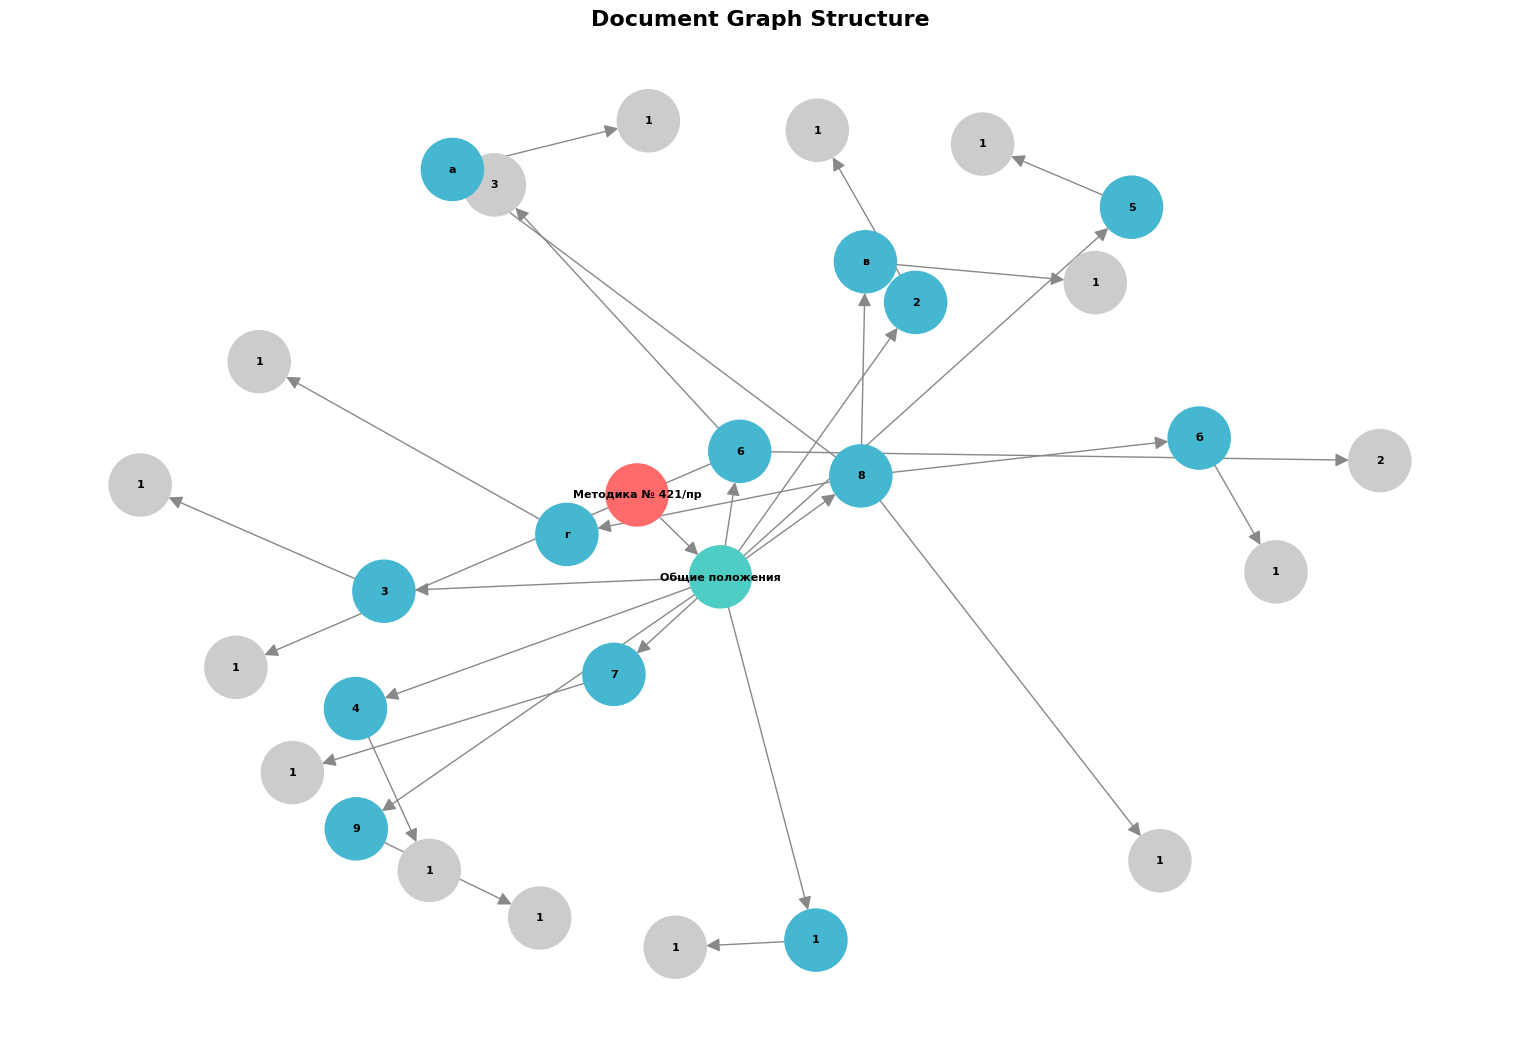

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph: DocumentGraph, max_nodes: int = 50):
    """Визуализирует граф."""
    G = nx.DiGraph()

    # Добавляем узлы
    for node_id, node in list(graph.nodes.items())[:max_nodes]:
        G.add_node(node_id, type=node.type.value, label=node.number or node.title or '')

    # Добавляем рёбра
    for edge in graph.edges:
        if edge.source_id in G and edge.target_id in G:
            G.add_edge(edge.source_id, edge.target_id, type=edge.type.value)

    # Визуализация
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # Цвета по типам
    color_map = {
        'document': '#FF6B6B',
        'section': '#4ECDC4',
        'point': '#45B7D1',
        'amendment': '#FFA07A',
        'replacement': '#98D8C8',
    }

    colors = [color_map.get(G.nodes[n]['type'], '#CCCCCC') for n in G.nodes()]

    nx.draw(G, pos, with_labels=True, labels={n: G.nodes[n]['label'] for n in G.nodes()},
            node_color=colors, node_size=2000, font_size=8, font_weight='bold',
            arrows=True, arrowsize=20, edge_color='#888888')

    plt.title("Document Graph Structure", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Показываем граф
print("📊 Визуализация графа...")
visualize_graph(doc_graph, max_nodes=30)